# Counterattack / Meeting Lines — a quantitative teardown 🔬
### Mechanical bullish meeting lines on 5 indices · forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a close-scramble geometry placebo · costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Meeting_forecasts%3F: Busted](https://img.shields.io/badge/Meeting_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **meeting** from the **drift**: a meeting line is a dip-buy after a down leg, and an upward-trending index makes *any* dip-buy look good, so the only meaningful test is meeting-vs-random, plus a placebo that drops the equal-close condition while keeping the down-leg/gap context.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Meeting = down leg (lookback 10), opposite-colour candles, gap-down open, closes within 15 bps; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from counterattack_lines import data, strategy as st

ASOF = "2026-05-31"
TOL = st.DEFAULT_TOL
LB = st.DEFAULT_TREND_LOOKBACK
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real meeting-line cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 280, 'tol_bps': 15, 'lookback': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 280, -7.6, 53, -0.46, 61.0, -68.6, -9.6, -3.01, 0.003), 'h10': (10, 280, 11.5, 55, 0.53, 73.0, -61.5, 9.5, -1.97, 0.049), 'h20': (20, 279, 111.3, 63, 3.5, 97.9, 13.4, 109.3, 0.33, 0.741), 'h60': (60, 278, 264.6, 70, 4.2, 118.0, 146.6, 262.6, 1.99, 0.047), 'per': [('SPY', 51, 41.1, 0.71, 36.7, 4.4), ('QQQ', 53, 193.6, 2.19, 129.9, 63.7), ('IWM', 47, 192.3, 3.03, 51.5, 140.8), ('DIA', 53, 53.5, 0.72, 38.1, 15.4), ('GLD', 76, 90.8, 1.57, 189.4, -98.7)], 'placebo': (41.1, 0.623, 500), 'syn': [(0.0, 68, -34.4, 46, -0.64), (0.6, 50, 595.9, 92, 9.86)]}


real meeting-line cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Meeting line vs a **drift-matched random** baseline: the meeting is *worse* at 5/10d (Δ = -69/-62 bps, Welch t at 5d = -3.01, **significantly negative**) and the meeting-minus-random difference **never clears t = 2** (max Welch t = +1.99 at 60d, p = 0.047). |
| **Tradability** | `MIRAGE` | The one-sample t's at long holds (20d t = 3.50, 60d t = 4.20) are **pure beta** — they vanish against random entries; at the short reversal horizon the pattern is a net negative. No residual edge to scale. |
| **Meeting forecasts?** | `BUSTED` | Dropping the equal-close condition (close-scramble placebo) leaves the result intact: **p = 0.62** of no-meeting down-leg dip-buys match or beat the real one. The meeting isn't doing the work. |

> 💡 In plain words: the meeting line *looks* okay only at long holds, because indices drift up. Strip the drift (race it vs random) or strip the meeting (drop the equal close) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

A bullish counterattack at bar $t$ requires: a down leg $C_{t-1}<C_{t-L}$ ($L=10$); a black candle $C_{t-1}<O_{t-1}$; a white candle $C_t>O_t$; a gap-down open $O_t<C_{t-1}$; and the **meeting** $|C_t-C_{t-1}|/C_{t-1}\le\tau$ ($\tau=15$ bps). The Andrews-style rule buys the close of $t$ and rides the reversal up.

- **H₀ (drift).** Meeting returns equal a drift-matched **random-entry** baseline.
- **H₁ (the meeting forecasts).** Meeting returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the equal close matters).** Meeting returns exceed a **close-scramble** pool that keeps the down-leg/gap context but drops the meeting.

We find **H₀ not rejected** (meeting ≤ random at 5–10d, *worse*), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.62). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* entry rule on a long-only horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of meeting-*minus*-random.

**(b) The dip vs the meeting.** A counterattack is *by construction* a dip-buy (it needs a down leg). The danger is that the whole signal is the dip, not the equal close. The **close-scramble placebo** keeps the down-leg + opposite-colour + gap context but draws entries that ignore the meeting — if the real result survives that, the equal close was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **280 bullish meeting lines** pooled.
- **Pattern.** Down leg (lookback 10), black candle t-1, white candle t, gap-down open, closes within 15 bps — all read at/before t (no look-ahead).
- **Entry.** Buy the meeting bar's close; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of meeting returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample meeting vs random (the *real* test).
- **Null #3 — close-scramble placebo** (equal close dropped, context kept).
- **Costs.** 1 bp one-way × 2 legs on every signal.
- **Positive control.** Synthetic tape with a **planted** meeting-bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks fine, vs-random kills it

Left: the meeting line's **one-sample** t against zero (the misleading number, at long holds). Right: the same meeting vs a **drift-matched random** baseline (the honest number).

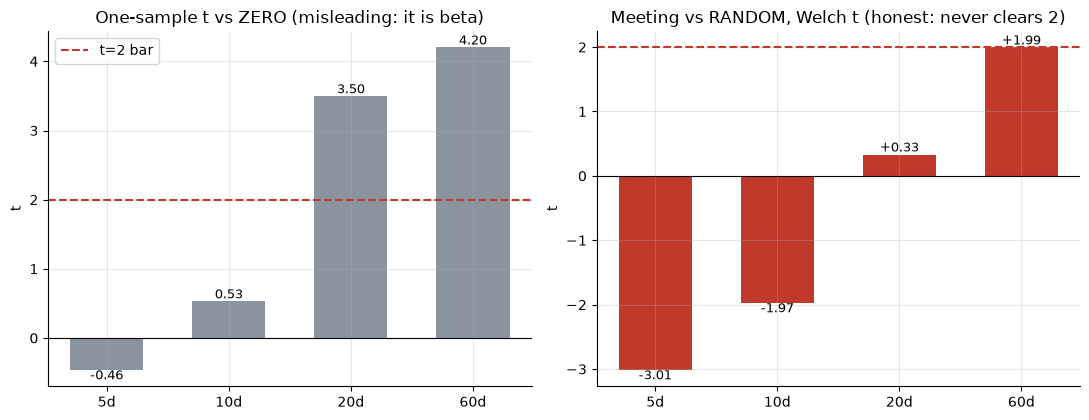

one-sample t: [-0.46, 0.53, 3.5, 4.2]
welch vs random: [np.float64(-3.01), np.float64(-1.97), np.float64(0.33), np.float64(1.99)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, meet, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.meeting_entries(bb, tol=TOL, trend_lookback=LB)
            re = st.random_entries(c, max(len(e),50), warmup=LB, seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); meet.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    meet = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Meeting vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 at long holds (20d **3.50**, 60d **4.20**) — but that's the **drift**, every dip-buy inherits it. The right bars are the real test: meeting-minus-random is **significantly negative** at 5d (-3.01) and only **+1.99** at 60d — never clears 2. The meeting adds nothing over a coin flip at the horizon it claims.

### 4b · Meeting vs random across horizons — the gap is the verdict

Mean return, meeting vs random entry, all four horizons. The meeting should tower over random at the short reversal horizon if it forecasts. It doesn't — it loses.

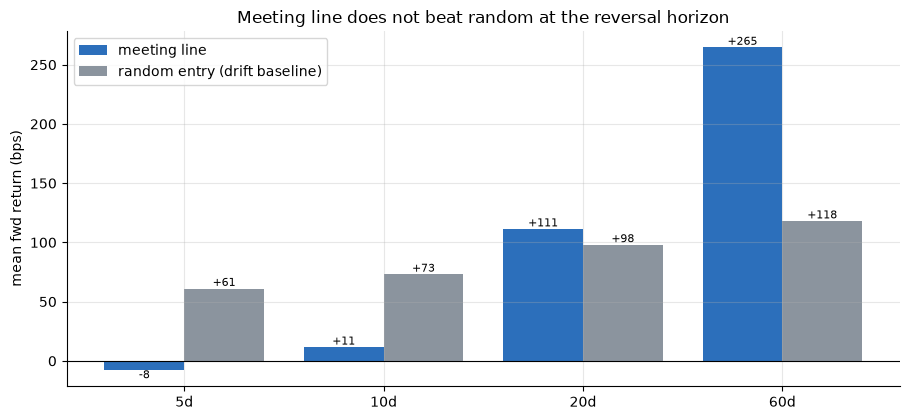

delta meeting-random (bps): [-69, -61, 13, 147]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, meet, .4, color='#2c6fbb', label='meeting line')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
ax.axhline(0, c='k', lw=.8)
for i,(a,b) in enumerate(zip(meet,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Meeting line does not beat random at the reversal horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('delta meeting-random (bps):', [round(a-b) for a,b in zip(meet,rnd)])

> 💡 In plain words: at 5 days the meeting is **-8 bps** but random is **+61 bps** — the pattern *underperforms* a dart by 69 bps right where the reversal should bite. The only horizons where it edges ahead are 20–60d, and the Welch test (4a) says that gap is noise.

### 4c · The geometry placebo — drop the meeting, nothing changes

Keep the down-leg + opposite-colour + gap-down context (the 'almost-meeting' candidates), but draw the same number of entries that **ignore the equal close**. If price respects *the meeting*, dropping it should demolish the result. The observed meeting return should sit far in the right tail of the no-meeting distribution. It doesn't.

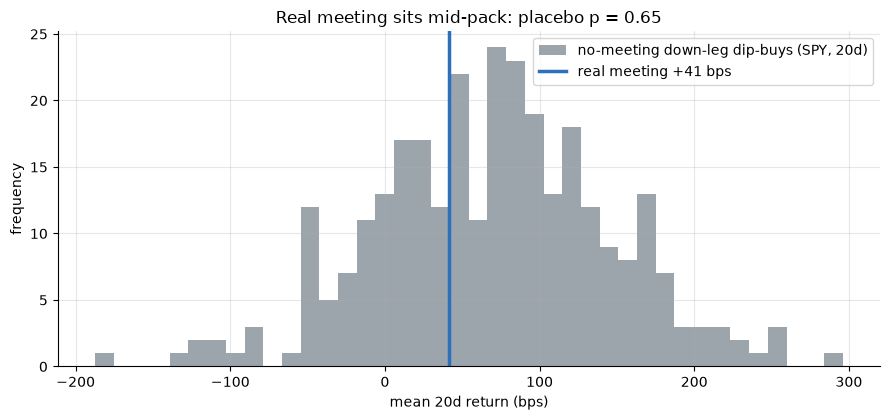

real meeting +41.1 bps   placebo p=0.65  (>0.05 => the equal close is not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY'); c = bb['close']
    pl = st.close_scramble_placebo(bb, 20, tol=TOL, trend_lookback=LB, n_draws=300, seed=460)
    obs = pl['obs']*1e4; pval = pl['p_value']
    cand = bb.index[st._candidate_mask(bb, trend_lookback=LB)]
    n_meet = len(st.meeting_entries(bb, tol=TOL, trend_lookback=LB))
    rng = np.random.default_rng(460); draws=[]
    cand_arr = np.asarray(cand)
    for _ in range(300):
        pick = rng.choice(cand_arr, size=n_meet, replace=False)
        import pandas as _pd
        rr = st.forward_returns(c, _pd.DatetimeIndex(sorted(pick)), 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(460); draws = rng.normal(40, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='no-meeting down-leg dip-buys (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real meeting {obs:+.0f} bps')
ax.set_xlabel('mean 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real meeting sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real meeting {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => the equal close is not load-bearing)')

> 💡 In plain words: the real meeting (blue line) sits **in the middle** of the no-meeting cloud — **p = 0.62**. Down-leg dip-buys that ignore the equal close do just as well, so the meeting itself carries no information. This is the cleanest refutation of 'the equal close forecasts.'

### 4d · Per-ticker — no coherent cross-sectional edge

20-day meeting-minus-random delta, per instrument. If the pattern worked it would be robustly positive; instead it rides on one small-cap name and is sharply negative in another.

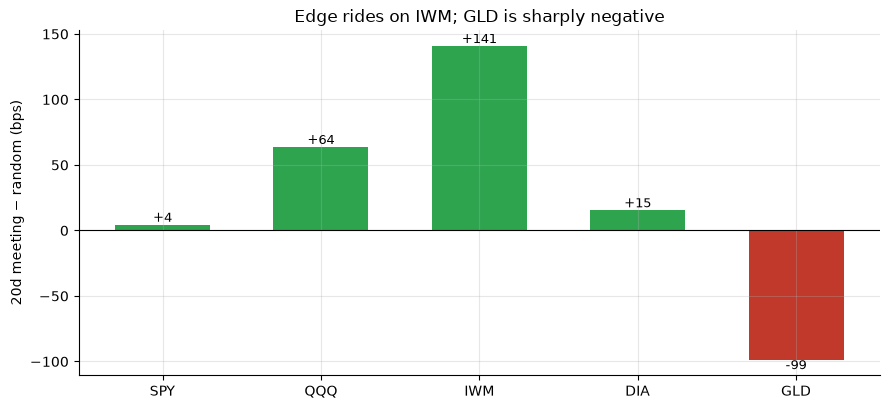

per-ticker 20d delta (bps): {'SPY': 4, 'QQQ': 64, 'IWM': 141, 'DIA': 15, 'GLD': -99}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.meeting_entries(bb, tol=TOL, trend_lookback=LB); re = st.random_entries(c, max(len(e),50), warmup=LB, seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d meeting − random (bps)'); ax.set_title('Edge rides on IWM; GLD is sharply negative')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: the whole 20d delta rides on **IWM** (+141 bps on just 47 signals — small-cap noise) while **GLD** is **-99** bps *behind* random. No coherent, cross-sectional edge — exactly what you'd expect if the meeting is just a relabelled dip.

### 4e · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** meeting-bounce into a synthetic tape and check the same rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

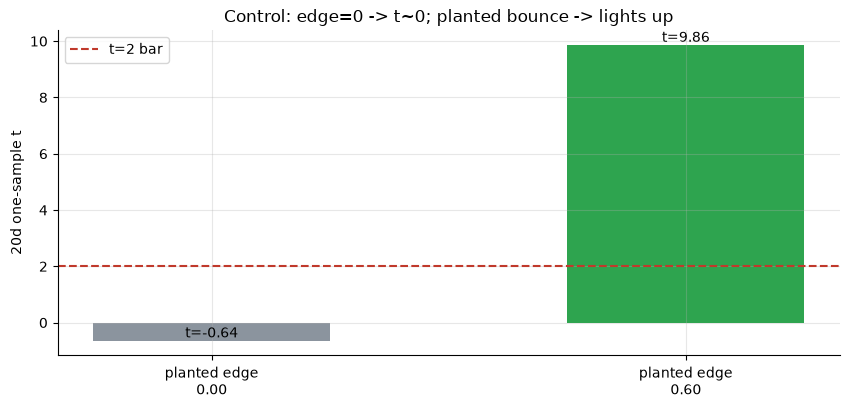

edge=0.00: n=68 meeting=-34.4bps win=46% t=-0.64
edge=0.60: n=50 meeting=+595.9bps win=92% t=+9.86


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=460, n_days=4000)
    e = st.meeting_entries(px, tol=TOL, trend_lookback=LB); s = st.summarize(st.forward_returns(px['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} meeting={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = -0.64** (win 46% — no false positive); a planted bounce reaches **t = 9.86** (win 92%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the meeting line does not beat a drift-matched random baseline (meeting − random = -69/-62/+13/+147 bps at 5/10/20/60d; Welch t is **significantly negative at 5d (-3.01)** and never clears 2, max **+1.99** at 60d, p = 0.047). The impressive one-sample t's (20d **3.50**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; at the short reversal horizon the pattern is a net negative, and costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Meeting forecasts? `BUSTED`** — the close-scramble placebo leaves the result untouched (**p = 0.62**): no-meeting down-leg dip-buys do as well as the real ones, so the defining equal close carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The meeting line's entire apparent profit is the unconditional drift of long equity indices at a 20–60 day hold, which you obtain more cheaply and more fully by **buying and holding**. At the short, supposedly-reversal horizon it *loses* to random. The rule trades *less* of the time (only on meetings) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The counterattack line is a descriptive candlestick label, not a forecasting strategy.

## 7 · Going further

- **The stronger relatives.** The *piercing line* (close above the prior midpoint) and *bullish engulfing* make a stronger close-geometry claim; the same harness applies and the same drift confound dominates.
- **Tolerance & lookback sweeps.** The equal-close band and down-leg window are free parameters; tightening or loosening them does not rescue the meeting — a robustness grid only confirms the drift-in/drift-out picture.
- **Bearish counterattack.** The mirror pattern (up leg, white then black candle closing to meet) inherits the symmetric drift problem on the short side.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*